In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
users = pd.read_csv("users.csv")
photos = pd.read_csv("photos.csv")
likes = pd.read_csv("likes.csv")
comments = pd.read_csv("comments.csv")
tags = pd.read_csv("tags.csv")
photo_tags = pd.read_csv("photo_tags.csv")
follows = pd.read_csv("follows.csv")


In [2]:
print(users.head())
print(photos.head())
print(likes.head())
print(comments.head())


   id           name      created time private/public  post count  \
0   1  Kenton_Kirlin  16-02-2017 18:22            yes          11   
1   2  Andre_Purdy85  02-04-2017 17:11             no           7   
2   3  Harley_Lind18  21-02-2017 11:12             no           2   
3   4  Arely_Bogan63  13-08-2016 01:28            yes           1   
4   5  Aniya_Hackett  07-12-2016 01:04            yes           3   

  Verified status  
0              no  
1              no  
2              no  
3              no  
4              no  
   id            image link  user ID       created dat Insta filter used  \
0   1     http://elijah.biz        1  13-04-2023 08:04               yes   
1   2    https://shanon.org        1  13-04-2023 08:04                no   
2   3      http://vicky.biz        1  13-04-2023 08:04                no   
3   4      http://oleta.net        1  13-04-2023 08:04                no   
4   5  https://jennings.biz        1  13-04-2023 08:04               yes   

  photo 

<Axes: title={'center': 'Photos Uploaded per User'}, xlabel='user ID'>

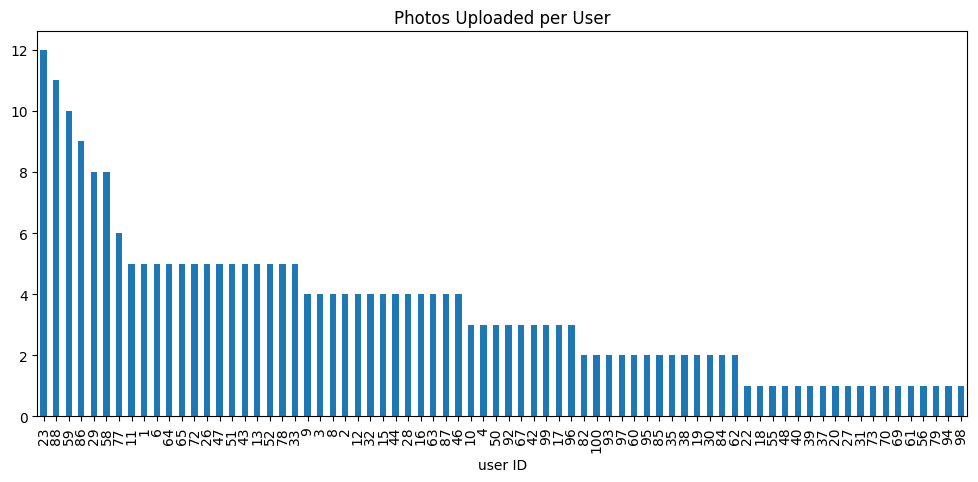

In [4]:
photos_per_user = photos['user ID'].value_counts()
photos_per_user.plot(kind='bar', figsize=(12,5), title="Photos Uploaded per User")

<Axes: title={'center': 'Top 10 Most Liked Photos'}, xlabel='photo'>

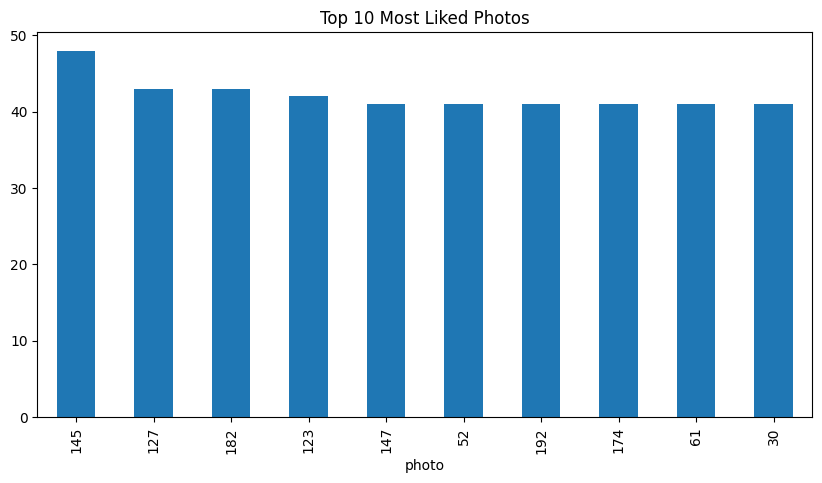

In [6]:
likes_count = likes['photo'].value_counts().head(10)
likes_count.plot(kind='bar', title="Top 10 Most Liked Photos", figsize=(10,5))

In [11]:
print(follows.head())
print(follows.describe())

   follower  followee       created time  is follower active  \
0         2          1  13-04-2023 08:04                   1   
1         2          3  13-04-2023 08:04                   0   
2         2          4  13-04-2023 08:04                   0   
3         2          5  13-04-2023 08:04                   0   
4         2          6  13-04-2023 08:04                   1   

  followee Acc status  
0             Private  
1             private  
2              public  
3             private  
4             private  
          follower    followee   is follower active
count  7623.000000  7623.000000         7623.000000
mean     48.519481    50.520005            0.550571
std      29.292942    28.862946            0.497469
min       2.000000     1.000000            0.000000
25%      22.000000    26.000000            0.000000
50%      46.000000    51.000000            1.000000
75%      72.000000    76.000000            1.000000
max     100.000000   100.000000            1.000000


<Axes: title={'center': 'Top 10 Most Active Commenters'}, xlabel='user_id_from_comments'>

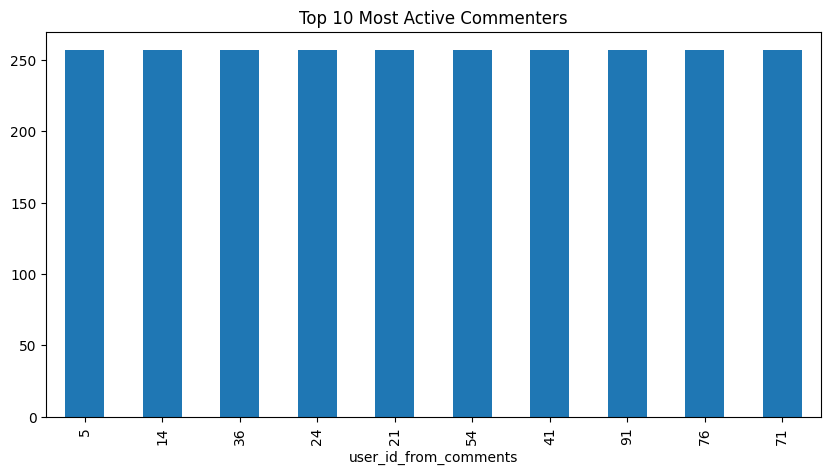

In [12]:
comments.columns = comments.columns.str.strip()
comments.rename(columns={comments.columns[2]: 'user_id_from_comments'}, inplace=True)
comments_per_user = comments['user_id_from_comments'].value_counts().head(10)
comments_per_user.plot(kind='bar', title="Top 10 Most Active Commenters", figsize=(10,5))

In [14]:
photo_tags.rename(columns={'tag ID': 'tag_id'}, inplace=True)
tags.rename(columns={'id': 'tag_id'}, inplace=True)
photo_tags_full = photo_tags.merge(tags, left_on="tag_id", right_on="tag_id", how="left")
print(photo_tags_full.head())

   photo  tag_id  user id tag text      created time       location
0      1      13        1      fun  13-04-2023 08:04         brazil
1      1      17        1    party  13-04-2023 08:04        florida
2      1      18        2  concert  13-04-2023 08:04  washington DC
3      1      19        2    drunk  13-04-2023 08:04       new york
4      1      21        3    smile  13-04-2023 08:04      australia


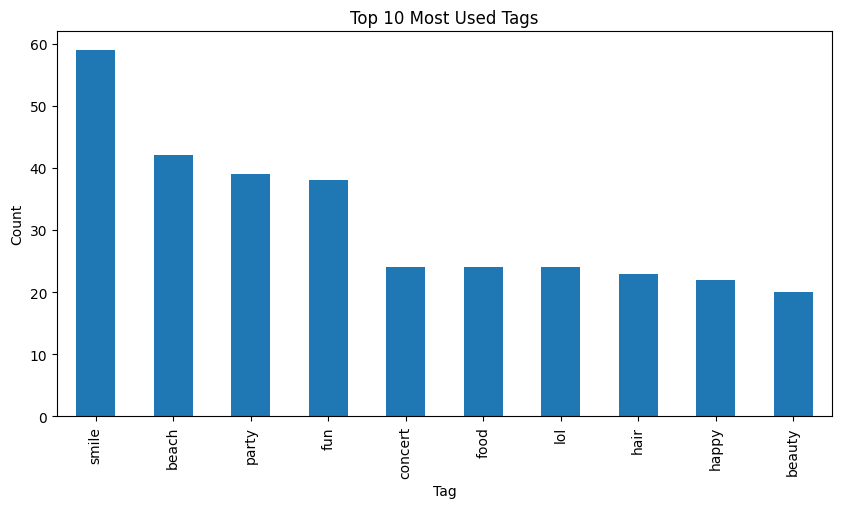

In [17]:
import matplotlib.pyplot as plt

tag_usage = photo_tags_full['tag text'].value_counts().head(10)

plt.figure(figsize=(10,5))
tag_usage.plot(kind='bar')
plt.title("Top 10 Most Used Tags")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.show()

In [19]:
# Count likes
like_count = likes.groupby('photo').size()

# Count comments
comment_count = comments.groupby('Photo id').size()

# Count tags
tag_count = photo_tags.groupby('photo').size()

# Combine all engagement
engagement_df = pd.DataFrame({
    'likes': like_count,
    'comments': comment_count,
    'tags': tag_count
}).fillna(0)

engagement_df['total_engagement'] = engagement_df['likes'] + engagement_df['comments'] + engagement_df['tags']

print(engagement_df.sort_values('total_engagement', ascending=False).head(10))


     likes  comments  tags  total_engagement
13      40        39   2.0              81.0
145     48        27   5.0              80.0
227     39        35   5.0              79.0
118     39        35   3.0              77.0
201     39        33   5.0              77.0
123     42        31   3.0              76.0
157     33        39   4.0              76.0
153     40        32   4.0              76.0
147     41        34   1.0              76.0
133     37        34   4.0              75.0


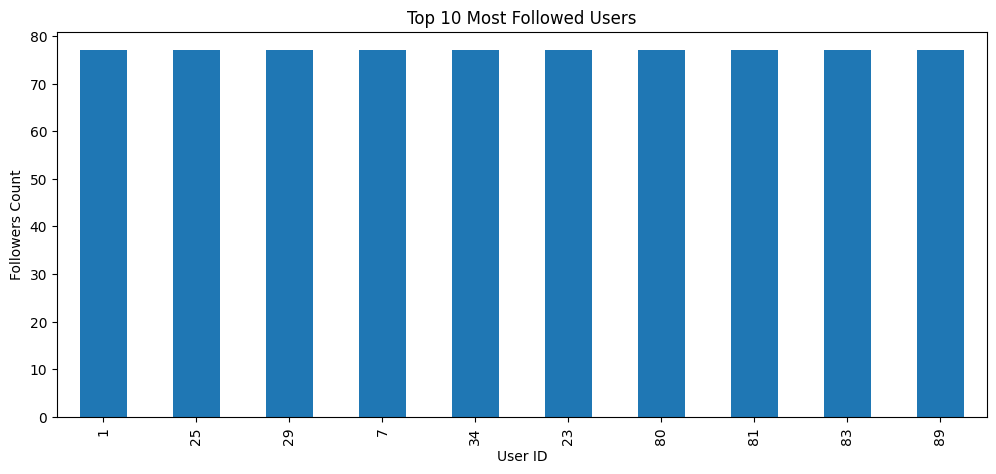

In [22]:
follows.columns = follows.columns.str.strip()
followers_count = follows['followee'].value_counts()

plt.figure(figsize=(12,5))
followers_count.head(10).plot(kind='bar')
plt.title("Top 10 Most Followed Users")
plt.xlabel("User ID")
plt.ylabel("Followers Count")
plt.show()

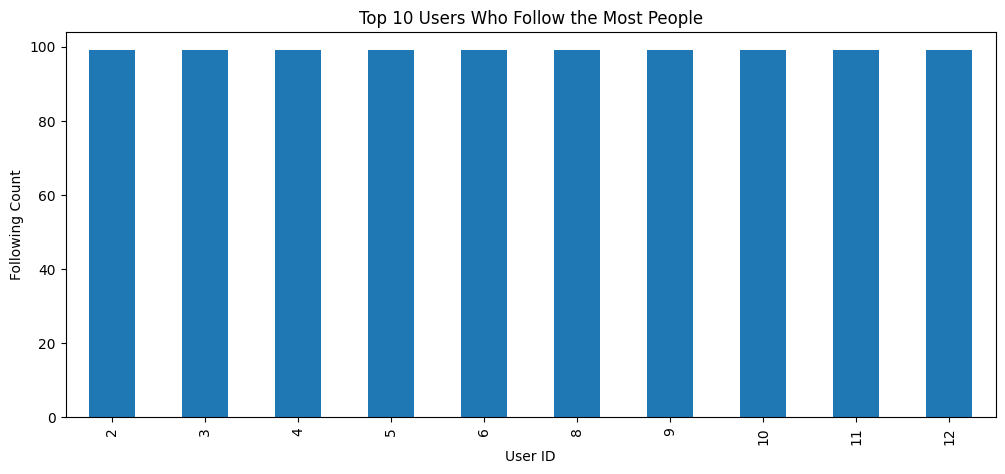

In [24]:
following_count = follows['follower'].value_counts()

plt.figure(figsize=(12,5))
following_count.head(10).plot(kind='bar')
plt.title("Top 10 Users Who Follow the Most People")
plt.xlabel("User ID")
plt.ylabel("Following Count")
plt.show()

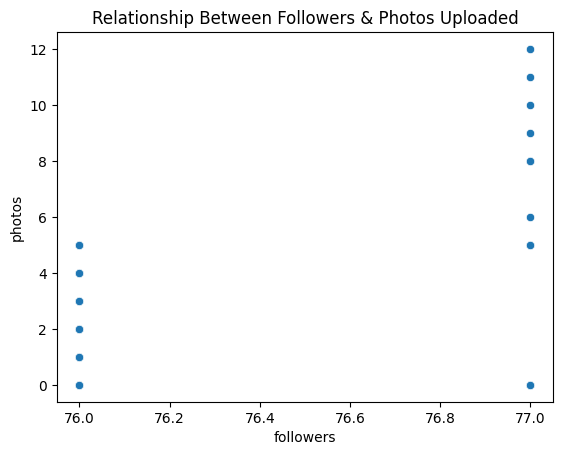

In [27]:
followers_count_df = followers_count.rename("followers").to_frame()
photos_count_df = photos['user ID'].value_counts().rename("photos").to_frame()

merged = followers_count_df.join(photos_count_df, how="left").fillna(0)

sns.scatterplot(data=merged, x="followers", y="photos")
plt.title("Relationship Between Followers & Photos Uploaded")
plt.show()

<Axes: title={'center': 'Top 10 Most Used Tags'}, xlabel='tag ID'>

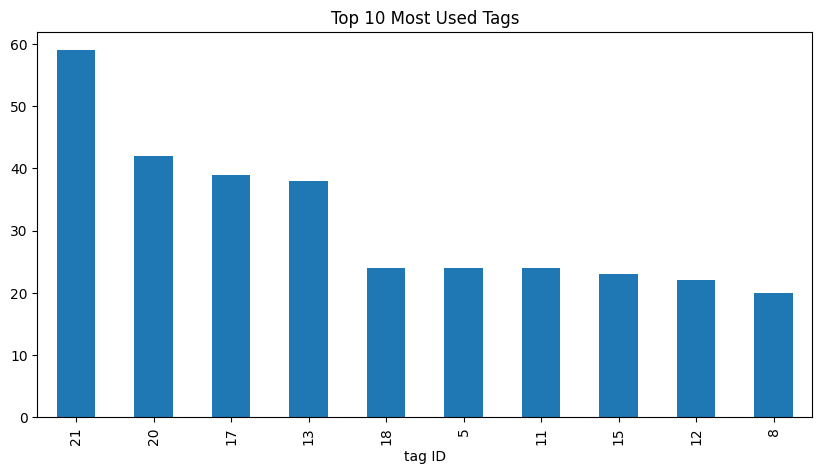

In [30]:
tags_count = photo_tags['tag ID'].value_counts().head(10)
tags_count.plot(kind='bar', title="Top 10 Most Used Tags", figsize=(10,5))

<Axes: title={'center': 'Top 10 Photos by Engagement'}, xlabel='photo'>

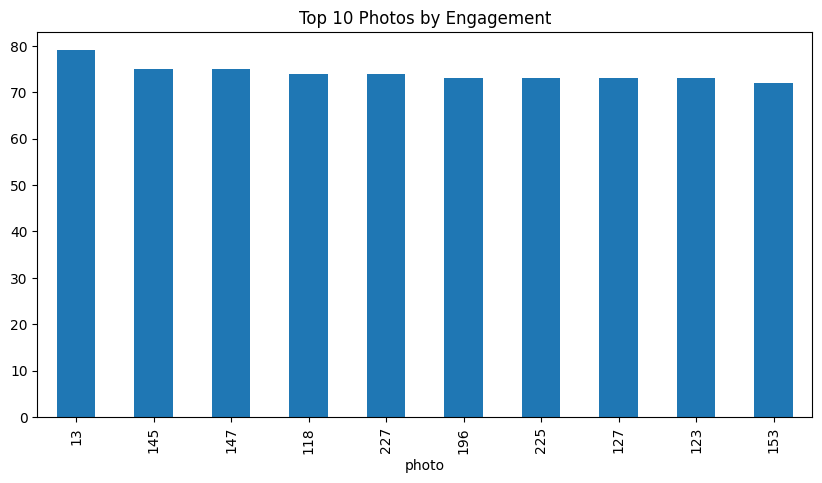

In [32]:
like_count = likes.groupby('photo').size()
comment_count = comments.groupby('Photo id').size()

engagement = (like_count + comment_count).sort_values(ascending=False).head(10)
engagement.plot(kind='bar', title='Top 10 Photos by Engagement', figsize=(10,5))